In [1]:
import cv2 
import mediapipe as mp


In [2]:
from mediapipe.tasks.python import vision
from mediapipe.tasks import python as mp_python
import mediapipe as mp

In [3]:
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles =mp.solutions.drawing_styles
mp_drawing_specs = mp_drawing.DrawingSpec(color = (0,255,0), thickness =1)


In [4]:
cap = cv2.VideoCapture(0)
mp_face_mesh = mp.solutions.face_mesh
with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks = True,
    min_detection_confidence =0.5,
    min_tracking_confidence = 0.5
) as face_mesh:
    while cap.isOpened():
        success, image = cap.read()
        if not success:
            break
        results= face_mesh.process(image)
        for face_landmarks in results.multi_face_landmakers:
            mp_drawing.draw_landmarks(
                image= image,
                landmark_list = face_landmarks,
                connections= mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec= None,
                connection_drawing_spec = mp_drawing_styles
                .get_default_face_mesh_tesselation_style()

            )
            mp_drawing.draw_landmarks(
                image= image,
                landmark_list = face_landmarks,
                connections= mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec= None,
                connection_drawing_spec = mp_drawing_specs
                    .get_default_face_mesh_contours_style()

            )

        
        cv2.imshow("My video capture", cv2.flip(image,1))
        if cv2.waitKey(100)== ord('q'):
            break
cap.release()
cv2.destroyAllWindows()

I0000 00:00:1772450637.366571       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


AttributeError: type object 'SolutionOutputs' has no attribute 'multi_face_landmakers'

: 

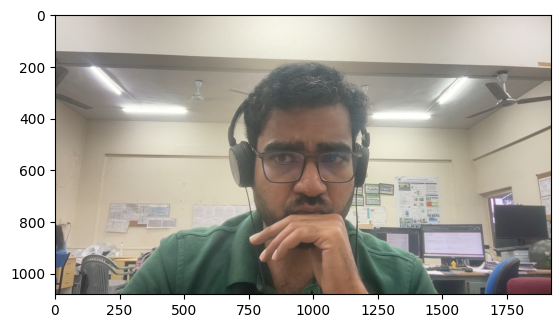

In [ ]:
#an expriment
success, image = cap.read()
if success:
    # Display using matplotlib instead
    import matplotlib.pyplot as plt
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.show()
cap.release()

In [ ]:
import cv2
import mediapipe
import matplotlib.pyplot as plt
import pandas as pd
img = cv2.imread("pexels-cottonbro-8090149.jpg")

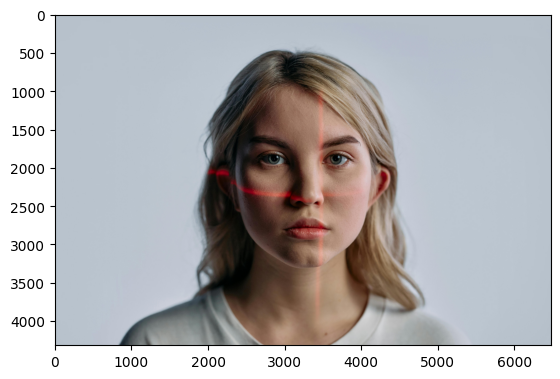

In [ ]:
plt.imshow(img[:,:,::-1])

In [ ]:
mp_face_mesh  = mediapipe.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode = True)

I0000 00:00:1772450192.232089       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro


In [ ]:
results = face_mesh.process(img[:,:,::-1])
results.multi_face_landmarks

[landmark {
   x: 0.50839514
   y: 0.62648433
   z: -0.03120908
 }
 landmark {
   x: 0.50796694
   y: 0.56567013
   z: -0.062065575
 }
 landmark {
   x: 0.5076076
   y: 0.58347756
   z: -0.0304844
 }
 landmark {
   x: 0.49635926
   y: 0.50390744
   z: -0.04873073
 }
 landmark {
   x: 0.5077096
   y: 0.5469621
   z: -0.0667854
 }
 landmark {
   x: 0.5071234
   y: 0.52192515
   z: -0.06285765
 }
 landmark {
   x: 0.50555557
   y: 0.4601987
   z: -0.033947453
 }
 landmark {
   x: 0.41481674
   y: 0.44744644
   z: 0.010891866
 }
 landmark {
   x: 0.5045246
   y: 0.41305894
   z: -0.028505445
 }
 landmark {
   x: 0.50425464
   y: 0.38740703
   z: -0.032916564
 }
 landmark {
   x: 0.5026567
   y: 0.2835678
   z: -0.024254367
 }
 landmark {
   x: 0.5085279
   y: 0.63558584
   z: -0.029511066
 }
 landmark {
   x: 0.5085682
   y: 0.6424074
   z: -0.025062228
 }
 landmark {
   x: 0.5085448
   y: 0.64519686
   z: -0.019509831
 }
 landmark {
   x: 0.508865
   y: 0.65112156
   z: -0.017112901
 }
 l

In [ ]:
landmarks = results.multi_face_landmarks[0]

In [ ]:
#lips =mp_face_mesh.FACEMESH_LIPS
face =mp_face_mesh.FaceMesh

In [ ]:
face

mediapipe.python.solutions.face_mesh.FaceMesh

In [ ]:
df = pd.DataFrame(list(face), columns=["p1", "p2"])

TypeError: 'type' object is not iterable

In [14]:
df.head()

,p1,p2
0,270,409
1,317,402
2,81,82
3,91,181
4,37,0


In [15]:
df.shape

(40, 2)

In [16]:
routes_idx = []
p1 = df.iloc[0]["p1"]
p2 = df.iloc[0]["p2"]

for i in range(0, df.shape[0]):
    obj =df[df["p1"]== p2]
    p1= obj["p1"].values[0]
    p2= obj["p2"].values[0]

    current_route = []
    current_route.append(p1)
    current_route.append(p2)
    routes_idx.append(current_route)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
for routes_idx in routes_idx[0:5]:
    print